In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df_ecommerce =  pd.read_csv('D:\Projetos\Visão de Cliente Único\df_ecommerce.csv',sep=',')

In [6]:
### Funções exploratórias para o E-commerce ###

def check_cross_state_purchases(df):
    """
    Verifica se existem clientes que compram de vendedores de outro estado.
    Retorna True se sim, False se não, e o número de compras interestaduais.
    """
    cross_state = df[df['customer_state'] != df['seller_state']]
    exists = len(cross_state) > 0
    count = len(cross_state)
    return exists, count

def top_selling_categories(df):
    """
    Retorna as categorias que mais vendem, baseado no valor total de pagamento.
    """
    sales = df.groupby('product_category_name')['payment_value'].sum().sort_values(ascending=False)
    return sales

def average_price_per_category(df):
    """
    Retorna a média de preço de compra por categoria.
    """
    avg = df.groupby('product_category_name')['payment_value'].mean().sort_values(ascending=False)
    return avg

def freight_payment_correlation(df):
    """
    Calcula a correlação entre o valor do frete e o valor do pagamento.
    Retorna o coeficiente de correlação.
    """
    corr = df['freight_value'].corr(df['payment_value'])
    return corr

def most_used_payment_types(df):
    """
    Retorna os tipos de pagamento mais utilizados.
    """
    counts = df['payment_type'].value_counts()
    return counts

def most_used_installments(df):
    """
    Retorna o número de parcelas mais utilizadas.
    """
    counts = df['payment_installments'].value_counts()
    return counts

def promoters_detractors(df):
    """
    Identifica clientes promotores (review_score 4-5) e detratores (review_score 1-2).
    Retorna contagem de promotores, detratores e total de reviews.
    """
    promoters = df[df['review_score'] >= 4]['review_score'].count()
    detractors = df[df['review_score'] <= 2]['review_score'].count()
    total = df['review_score'].count()
    return promoters, detractors, total

def rfm_analysis(df):
    """
    Realiza a análise RFM (Recência, Frequência, Valor Monetário) para os clientes.
    Retorna um DataFrame com as métricas RFM e scores algumas outras informações adicionais.
    """
    # Converter timestamp para datetime
    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
    
    # Data de referência: a data mais recente no dataset
    reference_date = df['order_purchase_timestamp'].max()
    
    # Calcular Recência: dias desde a última compra
    recency = df.groupby('CPF')['order_purchase_timestamp'].max().apply(lambda x: (reference_date - x).days)
    
    # Calcular Frequência: número de pedidos únicos por cliente
    frequency = df.groupby('CPF')['order_id'].nunique()
    
    # Calcular Valor Monetário: soma dos valores de pagamento por cliente
    monetary = df.groupby('CPF')['payment_value'].sum()
    
    # Primeira compra
    first_purchase = df.groupby('CPF')['order_purchase_timestamp'].min()
    
    # Última compra
    last_purchase = df.groupby('CPF')['order_purchase_timestamp'].max()
    
    # Média de avaliações
    avg_review = df.groupby('CPF')['review_score'].mean()
    
    # Média de intervalos entre compras
    def avg_interval(group):
        if len(group) > 1:
            dates = sorted(group['order_purchase_timestamp'].unique())
            diffs = [(dates[i+1] - dates[i]).days for i in range(len(dates)-1)]
            return sum(diffs) / len(diffs) if diffs else 0
        else:
            return 0  # ou np.nan
    
    avg_purchase_interval = df.groupby('CPF').apply(avg_interval)
    
    # Categoria mais comprada e valor gasto nela
    def most_bought_category(group):
        cat_sum = group.groupby('product_category_name')['payment_value'].sum()
        top_cat = cat_sum.idxmax()
        top_value = cat_sum.max()
        return pd.Series({'Top_Category': top_cat, 'Top_Category_Value': top_value})
    
    top_cat_info = df.groupby('CPF').apply(most_bought_category)
    
    # Combinar em um DataFrame
    rfm = pd.DataFrame({
        'Recency': recency,
        'Frequency': frequency,
        'Monetary': monetary,
        'First_Purchase': first_purchase,
        'Last_Purchase': last_purchase,
        'Avg_Review_Score': avg_review,
        'Avg_Purchase_Interval': avg_purchase_interval
    })
    
    # Adicionar as colunas de categoria
    rfm = rfm.join(top_cat_info)
    
    # Calcular scores
    # Recency: menor = melhor (score 4)
    rfm['R_Score'] = pd.qcut(-rfm['Recency'], 4, labels=[4, 3, 2, 1], duplicates='drop')
    
    # Frequency: maior = melhor (score 4), mas como muitos têm 1, usar cut customizado
    rfm['F_Score'] = pd.cut(rfm['Frequency'], bins=[0, 1, 2, 5, float('inf')], labels=[1, 2, 3, 4], include_lowest=True, right=False)
    
    # Monetary: maior = melhor (score 4)
    rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4], duplicates='drop')
    
    # Segmentação baseada nos scores
    rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
    
    # Definir segmentos
    def segment_customer(row):
        r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
        if r == 4 and f == 4 and m == 4:
            return 'Campeões'
        elif r >= 3 and f >= 3 and m >= 3:
            return 'Clientes Valiosos'
        elif r >= 3 and f >= 1 and m >= 1:
            return 'Clientes Recentes'
        elif r >= 2 and f >= 2 and m >= 2:
            return 'Clientes Fiéis'
        elif r == 1:
            return 'Clientes Perdidos'
        elif f == 1:
            return 'Clientes de Baixa Frequência'
        else:
            return 'Outros'
    
    rfm['Segmento'] = rfm.apply(segment_customer, axis=1)
    
    return rfm

In [7]:
# Chamando as funções para responder às perguntas de negócio

print("1. Existe cliente que compra coisas de outro estado?")
exists, count = check_cross_state_purchases(df_ecommerce)
print(f"Sim, existem {count} compras interestaduais." if exists else "Não, todas as compras são no mesmo estado.")

print("\n2. Quais são as categorias que mais vendem?")
top_cat = top_selling_categories(df_ecommerce)
print(top_cat.head(10))  # Top 10

print("\n3. Qual é a média de preço de comprar por categoria?")
avg_price = average_price_per_category(df_ecommerce)
print(avg_price.head(10))  # Top 10 médias

print("\n4. Existe alguma correlação do tipo, quanto maior o frete, menor é a compra?")
corr = freight_payment_correlation(df_ecommerce)
print(f"Coeficiente de correlação: {corr:.4f}")
if corr > 0:
    print("Há uma correlação positiva: quanto maior o frete, maior a compra.")
elif corr < 0:
    print("Há uma correlação negativa: quanto maior o frete, menor a compra.")
else:
    print("Não há correlação linear.")

print("\n5. Quais são os tipos de pagamento que mais são utilizados?")
pay_types = most_used_payment_types(df_ecommerce)
print(pay_types)

print("\n6. Qual o número de parcelas que são mais utilizadas?")
install = most_used_installments(df_ecommerce)
print(install)

print("\n7. Existem clientes que são promotores? E detratores?")
prom, det, tot = promoters_detractors(df_ecommerce)

print(f"Promotores (score 4-5): {prom}")
print(f"Detratores (score 1-2): {det}")
print(f"Total de reviews: {tot}")
nps = (prom - det) / tot * 100 if tot > 0 else 0
print(f"NPS aproximado: {nps:.2f}%")
# Análise RFM
print("\n8. Análise RFM dos clientes:")
rfm_df = rfm_analysis(df_ecommerce)
print(rfm_df.head(10))  # Mostra os primeiros 10 clientes

print("\n9. Distribuição dos segmentos (em %):")
segment_dist = rfm_df['Segmento'].value_counts(normalize=True) * 100
print(segment_dist.round(2).astype(str) + '%')

print("\n10. Estatísticas descritivas das métricas RFM:")
print(rfm_df[['Recency', 'Frequency', 'Monetary']].describe())

print("\nDiagnostico: A análise RFM revelou que a maioria dos clientes tem baixa frequência e valor monetário, indicando que muitos são compradores ocasionais. A recência média sugere que muitos clientes não compram há algum tempo, o que pode indicar um risco de churn. Os segmentos mais comuns são 'Clientes Recentes' e 'Clientes de Baixa Frequência', sugerindo que a empresa tem uma base de clientes grande, mas com baixo engajamento. Estratégias de reativação e fidelização podem ser necessárias para aumentar a retenção e o valor dos clientes.")





1. Existe cliente que compra coisas de outro estado?
Sim, existem 73871 compras interestaduais.

2. Quais são as categorias que mais vendem?
product_category_name
cama_mesa_banho           1725465.67
beleza_saude              1646292.53
informatica_acessorios    1592611.66
moveis_decoracao          1427214.01
relogios_presentes        1420682.17
esporte_lazer             1390581.87
utilidades_domesticas     1091709.15
ferramentas_jardim         834757.45
automotivo                 802254.74
cool_stuff                 772616.70
Name: payment_value, dtype: float64

3. Qual é a média de preço de comprar por categoria?
product_category_name
pcs                                 1244.453502
telefonia_fixa                       767.301152
portateis_casa_forno_e_cafe          656.786154
agro_industria_e_comercio            471.153214
eletrodomesticos_2                   464.267313
moveis_escritorio                    364.313553
sinalizacao_e_seguranca              343.163166
construcao_ferramen

C:\Users\oguis\AppData\Local\Temp\ipykernel_24984\1363449079.py:97: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_purchase_interval = df.groupby('CPF').apply(avg_interval)


                Recency  Frequency  Monetary      First_Purchase  \
CPF                                                                
100.267.719-28       16         22   4192.78 2017-02-04 19:01:27   
100.365.590-89       87         17   2339.60 2017-02-02 12:37:02   
100.645.545-88       55         28   7310.35 2016-10-07 22:46:51   
100.801.480-85       63         22   3207.40 2017-06-07 19:19:35   
100.998.840-95       25         22   3863.43 2017-04-06 15:58:17   
101.332.468-59       12         22   2802.83 2017-03-12 09:38:04   
101.489.665-13       16         24   3099.54 2017-01-21 08:50:04   
101.635.817-73       15         25   4023.89 2017-02-28 13:40:03   
102.127.480-38       37         26   3554.92 2017-01-25 11:45:19   
102.674.847-73       20         19   1985.64 2017-01-23 22:23:01   

                     Last_Purchase  Avg_Review_Score  Avg_Purchase_Interval  \
CPF                                                                           
100.267.719-28 2018-08-17

C:\Users\oguis\AppData\Local\Temp\ipykernel_24984\1363449079.py:106: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_cat_info = df.groupby('CPF').apply(most_bought_category)


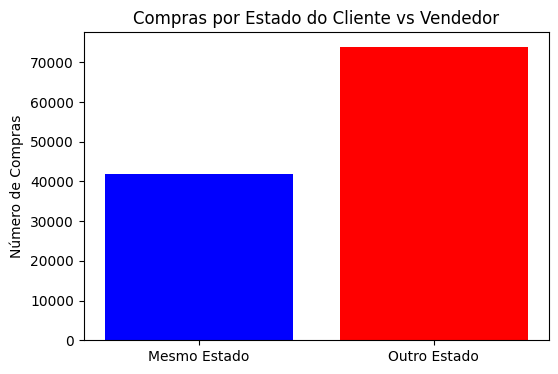

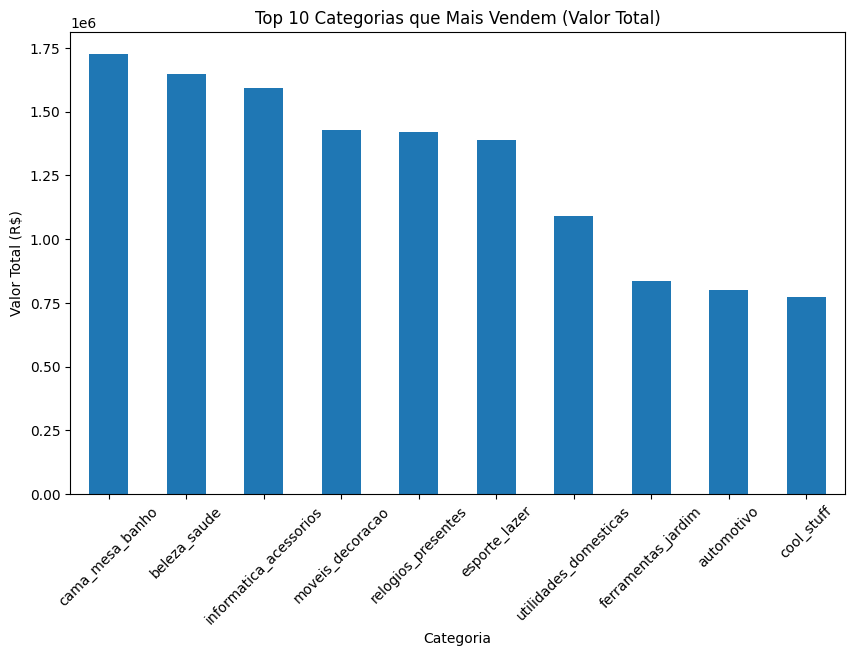

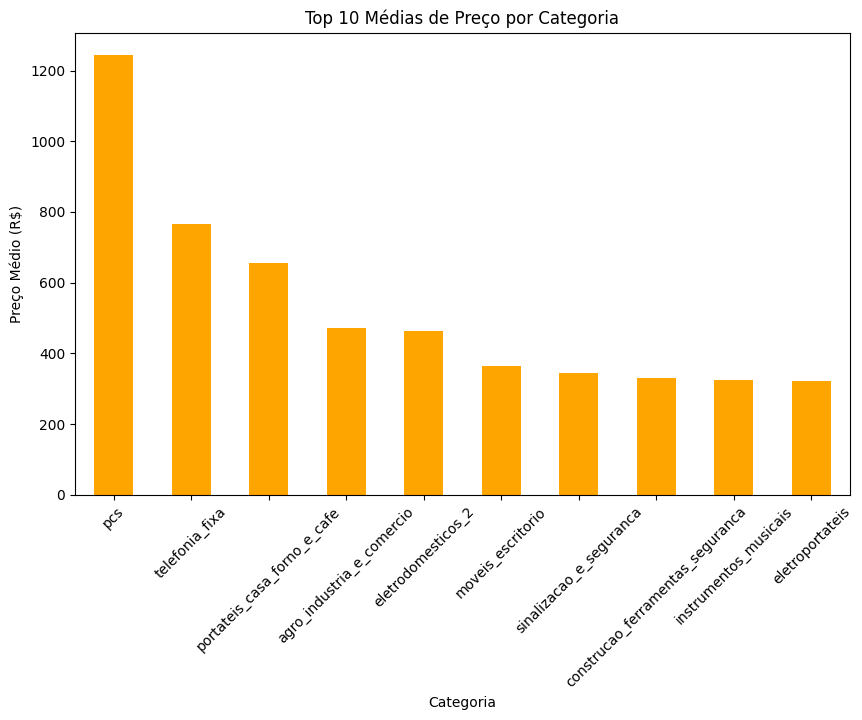

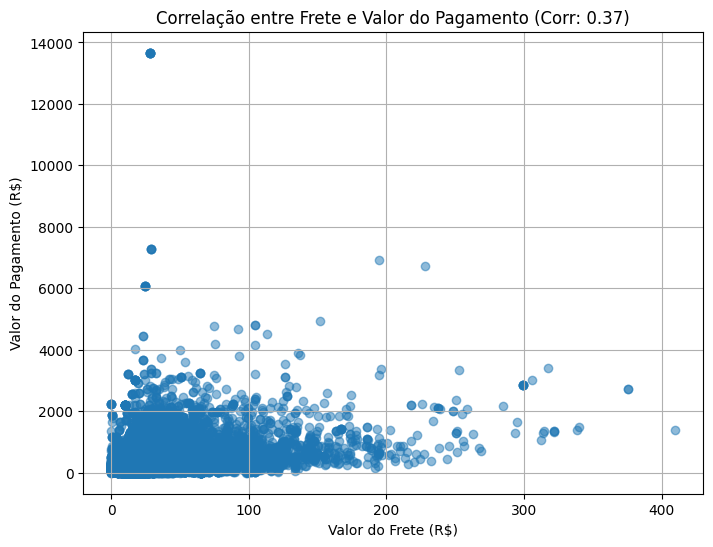

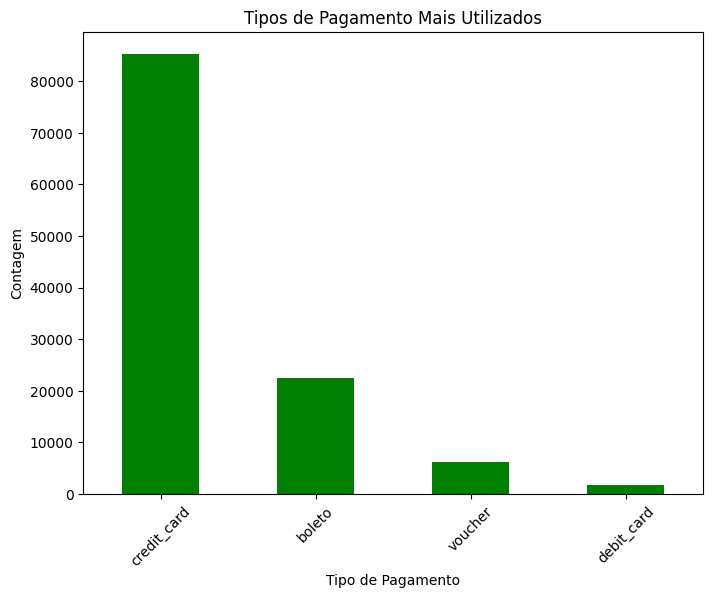

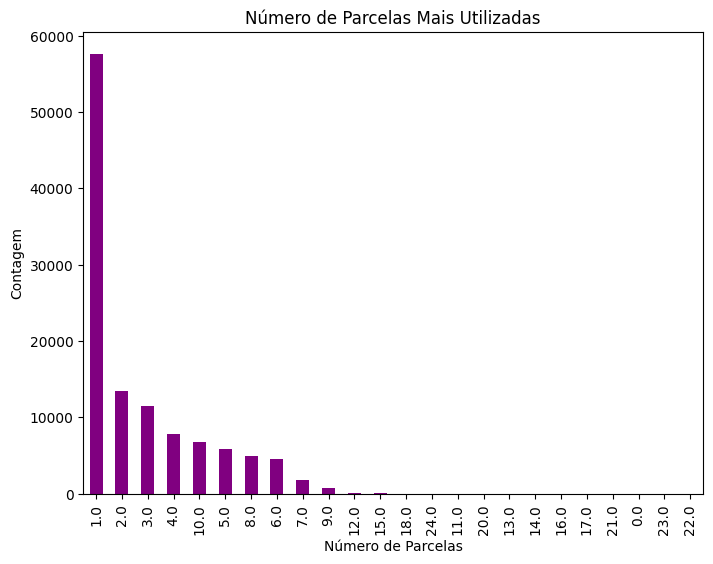

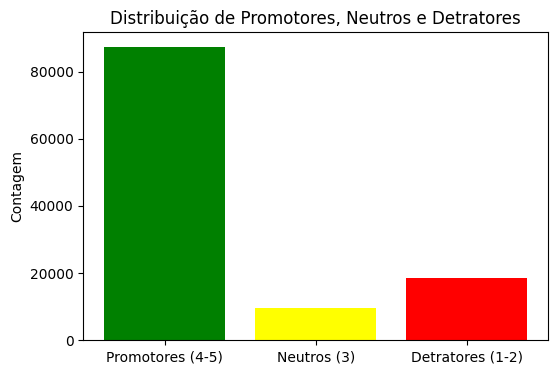

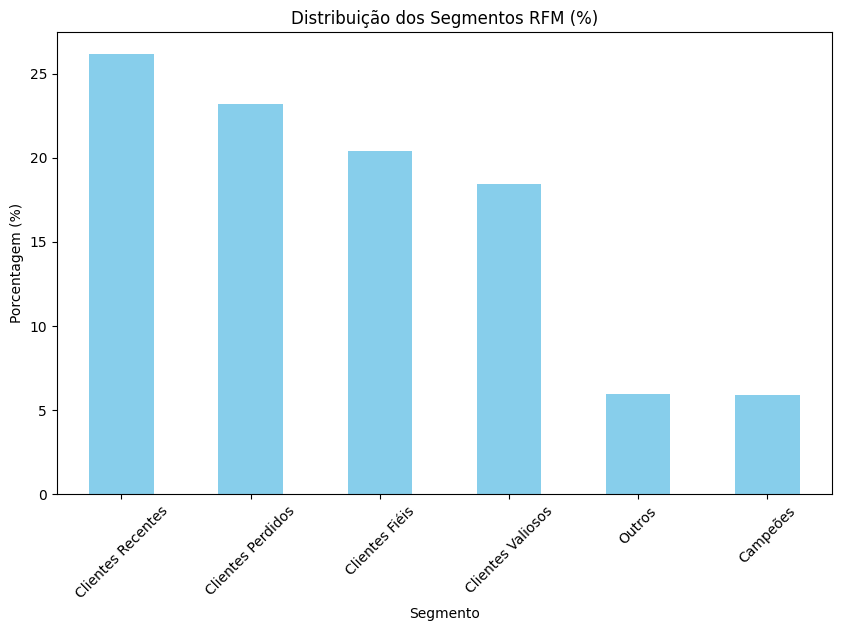

In [8]:
# Visualizações das respostas de negócio

# 1. Compras interestaduais
exists, count = check_cross_state_purchases(df_ecommerce)
total_orders = len(df_ecommerce)
labels = ['Mesmo Estado', 'Outro Estado']
sizes = [total_orders - count, count]
plt.figure(figsize=(6,4))
plt.bar(labels, sizes, color=['blue', 'red'])
plt.title('Compras por Estado do Cliente vs Vendedor')
plt.ylabel('Número de Compras')
plt.show()

# 2. Categorias que mais vendem
top_cat = top_selling_categories(df_ecommerce).head(10)
plt.figure(figsize=(10,6))
top_cat.plot(kind='bar')
plt.title('Top 10 Categorias que Mais Vendem (Valor Total)')
plt.xlabel('Categoria')
plt.ylabel('Valor Total (R$)')
plt.xticks(rotation=45)
plt.show()

# 3. Média de preço por categoria
avg_price = average_price_per_category(df_ecommerce).head(10)
plt.figure(figsize=(10,6))
avg_price.plot(kind='bar', color='orange')
plt.title('Top 10 Médias de Preço por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Preço Médio (R$)')
plt.xticks(rotation=45)
plt.show()

# 4. Correlação frete vs pagamento
corr = freight_payment_correlation(df_ecommerce)
plt.figure(figsize=(8,6))
plt.scatter(df_ecommerce['freight_value'], df_ecommerce['payment_value'], alpha=0.5)
plt.title(f'Correlação entre Frete e Valor do Pagamento (Corr: {corr:.2f})')
plt.xlabel('Valor do Frete (R$)')
plt.ylabel('Valor do Pagamento (R$)')
plt.grid(True)
plt.show()

# 5. Tipos de pagamento
pay_types = most_used_payment_types(df_ecommerce)
plt.figure(figsize=(8,6))
pay_types.plot(kind='bar', color='green')
plt.title('Tipos de Pagamento Mais Utilizados')
plt.xlabel('Tipo de Pagamento')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

# 6. Número de parcelas
install = most_used_installments(df_ecommerce)
plt.figure(figsize=(8,6))
install.plot(kind='bar', color='purple')
plt.title('Número de Parcelas Mais Utilizadas')
plt.xlabel('Número de Parcelas')
plt.ylabel('Contagem')
plt.show()

# 7. Promotores e detratores
prom, det, tot = promoters_detractors(df_ecommerce)
neutrals = tot - prom - det
labels = ['Promotores (4-5)', 'Neutros (3)', 'Detratores (1-2)']
sizes = [prom, neutrals, det]
plt.figure(figsize=(6,4))
plt.bar(labels, sizes, color=['green', 'yellow', 'red'])
plt.title('Distribuição de Promotores, Neutros e Detratores')
plt.ylabel('Contagem')
plt.show()

# RFM: Distribuição dos segmentos
segment_dist = rfm_df['Segmento'].value_counts(normalize=True) * 100
plt.figure(figsize=(10,6))
segment_dist.plot(kind='bar', color='skyblue')
plt.title('Distribuição dos Segmentos RFM (%)')
plt.xlabel('Segmento')
plt.ylabel('Porcentagem (%)')
plt.xticks(rotation=45)
plt.show()